In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport
import geopandas as gpd
import plotly.express as px 
from tqdm import tqdm






In [56]:
dtype_mappings = {
    'Incident ID': 'int64',
    'Offense Code': 'int64',#need fixing 3 data unknow 2_ FTAS and 1_ NSUP
    'CR Number': 'int64',
    'Dispatch Date / Time': 'string',
    'NIBRS Code': 'string',
    'Victims': 'int64',
    'Crime Name1': 'category',#Categorical
    'Crime Name2': 'string',
    'Crime Name3': 'string',
    'Police District Name': 'string',# need fixing
    'Block Address': 'string',
    'City': 'string',
    'State': 'string',
    'Zip Code': 'int64',
    'Agency': 'string',
    'Place':'string',
    'Sector':'string',
    'Beat':'string',
    'PRA':'string',#need fixing
    'Address Number':'int64', #some entry are na fill with 0
    'Street Prefix':'string',
    'Street Name':'string',
    'Street Suffix':'string',
    'Street Type':'string',
    'Start_Date_Time':'string',
    'End_Date_Time':'string',
    'Latitude':'float64',
    'Longitude':'float64',
    'Police District Number': 'string',#need to be in category
    'Location': 'string'
}

In [62]:
cd =pd.read_csv('./data/Crime_Dataset_Cleaned.csv', dtype=dtype_mappings, parse_dates=['Dispatch Date / Time', 'Start_Date_Time', 'End_Date_Time'])
cd['Crime Name1'] = cd['Crime Name1'].astype('category')

/var/folders/s0/0t4b0q1x7rj9l6hs1khgqxsr0000gn/T/ipykernel_86261/2702107104.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cd =pd.read_csv('./data/Crime_Dataset_Cleaned.csv', dtype=dtype_mappings, parse_dates=['Dispatch Date / Time', 'Start_Date_Time', 'End_Date_Time'])


In [58]:
cd.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 280865 entries, 0 to 280864
Data columns (total 30 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   Incident ID             280865 non-null  int64         
 1   Offence Code            280865 non-null  int64         
 2   CR Number               280865 non-null  int64         
 3   Dispatch Date / Time    280865 non-null  datetime64[ns]
 4   NIBRS Code              280865 non-null  string        
 5   Victims                 280865 non-null  int64         
 6   Crime Name1             280627 non-null  category      
 7   Crime Name2             280627 non-null  string        
 8   Crime Name3             280627 non-null  string        
 9   Police District Name    280865 non-null  string        
 10  Block Address           280865 non-null  string        
 11  City                    280865 non-null  string        
 12  State                   280865

In [35]:
#missing data
missing_data = cd.isnull().sum()

In [36]:
missing_data

Incident ID                    0
Offence Code                   0
CR Number                      0
Dispatch Date / Time           0
NIBRS Code                     0
Victims                        0
Crime Name1                  238
Crime Name2                  238
Crime Name3                  238
Police District Name           0
Block Address                  0
City                           0
State                          0
Zip Code                       0
Agency                         0
Place                          0
Sector                      1438
Beat                        1438
PRA                          229
Address Number                 0
Street Prefix             268411
Street Name                    0
Street Suffix             275979
Street Type                  304
Start_Date_Time                0
End_Date_Time                  0
Latitude                       0
Longitude                      0
Police District Number         0
Location                       0
dtype: int

In [37]:
cd[cd['End_Date_Time']=='<NA>']


,Incident ID,Offence Code,CR Number,Dispatch Date / Time,NIBRS Code,Victims,Crime Name1,Crime Name2,Crime Name3,Police District Name,...,Street Prefix,Street Name,Street Suffix,Street Type,Start_Date_Time,End_Date_Time,Latitude,Longitude,Police District Number,Location
0,201202980,3550,180042096,2018-08-23 21:52:08,35B,1,Crime Against Society,Drug Equipment Violations,DRUGS - NARCOTIC EQUIP - POSSESS,GERMANTOWN,...,<NA>,MIDDLEBROOK,<NA>,RD,2018-08-23 21:52:00,<NA>,39.177744,-77.265619,5D,"(39.1777, -77.2656)"
1,201181293,3522,180015424,2018-03-30 01:00:55,35A,1,Crime Against Society,Drug/Narcotic Violations,DRUGS - OPIUM OR DERIVATIVE - POSSESS,BETHESDA,...,<NA>,WOODMONT,<NA>,AVE,2018-03-30 01:01:00,<NA>,38.992693,-77.097063,2D,"(38.9927, -77.0971)"
4,201121509,5213,17008780,2017-02-18 00:18:00,520,1,Crime Against Society,Weapon Law Violations,WEAPON - FIRING,WHEATON,...,<NA>,PUNCH,<NA>,ST,2017-02-18 00:18:00,<NA>,39.088902,-77.042262,4D,"(39.0889, -77.0423)"
6,201108886,1399,16060247,2016-11-20 09:00:00,13B,1,Crime Against Person,Simple Assault,ASSAULT - 2ND DEGREE,SILVER SPRING,...,<NA>,NORTHAMPTON,<NA>,DR,2016-11-20 09:00:00,<NA>,39.008359,-76.985601,3D,"(39.0084, -76.9856)"
7,201124327,9199,17012248,2017-03-08 14:03:00,90Z,1,Other,All Other Offenses,POLICE INFORMATION,WHEATON,...,<NA>,GEORGIA,<NA>,AVE,2017-03-08 14:03:00,<NA>,39.036218,-77.049887,4D,"(39.0362, -77.0499)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
280859,201330811,2902,210018244,2021-05-14 23:19:11,290,1,Crime Against Property,Destruction/Damage/Vandalism of Property,DAMAGE PROPERTY - PRIVATE,WHEATON,...,<NA>,GEORGIA,<NA>,AVE,2021-05-14 20:45:00,<NA>,39.041513,-77.051713,4D,"(39.0415, -77.0517)"
280860,201320571,1399,210006666,2021-02-21 07:25:28,13B,1,Crime Against Person,Simple Assault,ASSAULT - 2ND DEGREE,MONTGOMERY VILLAGE,...,<NA>,TRANSHIRE,<NA>,RD,2021-02-20 20:00:00,<NA>,39.172701,-77.197340,6D,"(39.1727, -77.1973)"
280861,201329875,2305,210017101,2021-05-06 22:54:47,23F,1,Crime Against Property,Theft From Motor Vehicle,LARCENY - FROM AUTO,WHEATON,...,<NA>,ATHERTON,<NA>,DR,2021-05-06 03:15:00,<NA>,39.059672,-77.075995,4D,"(39.0597, -77.076)"
280862,201329751,5016,210016952,2021-05-05 22:38:58,90Z,1,Crime Against Society,All Other Offenses,OBSTRUCT GOVT - VIOLATION OF A COURT ORDER,GERMANTOWN,...,<NA>,BALTUSROL,<NA>,DR,2021-05-05 22:38:00,<NA>,39.199722,-77.273039,5D,"(39.1997, -77.273)"


In [66]:
#find latitude and longitude missing values if 0 
missing_lat_lon = cd[(cd['Latitude'] == 0) | (cd['Longitude'] == 0)]
missing_lat_lon


,Incident ID,Offence Code,CR Number,Dispatch Date / Time,NIBRS Code,Victims,Crime Name1,Crime Name2,Crime Name3,Police District Name,Block Address,City,State,Zip Code,Agency,Place,Sector,Beat,PRA,Address Number,Street Prefix,Street Name,Street Suffix,Street Type,Start_Date_Time,End_Date_Time,Latitude,Longitude,Police District Number,Location


In [39]:
cd.sample(5)

,Incident ID,Offence Code,CR Number,Dispatch Date / Time,NIBRS Code,Victims,Crime Name1,Crime Name2,Crime Name3,Police District Name,...,Street Prefix,Street Name,Street Suffix,Street Type,Start_Date_Time,End_Date_Time,Latitude,Longitude,Police District Number,Location
109214,201100683,2902,16050080,2016-09-29 09:30:00,290,1,Crime Against Property,Destruction/Damage/Vandalism of Property,DAMAGE PROPERTY - PRIVATE,BETHESDA,...,<NA>,GLENRIDGE,<NA>,ST,2016-09-29 09:30:00,<NA>,39.017537,-77.087483,2D,"(39.0175, -77.0875)"
251580,201302444,2304,200036574,2020-09-18 08:46:41,23G,1,Crime Against Property,Theft of Motor Vehicle Parts or Accessories,LARCENY - AUTO PARTS,BETHESDA,...,<NA>,WEYMOUTH,<NA>,ST,2020-09-16 09:04:00,2020-09-18 08:56:00,39.028544,-77.096344,2D,"(39.0285, -77.0963)"
129541,201119496,2305,17006368,2017-02-04 19:00:00,23F,1,Crime Against Property,Theft From Motor Vehicle,LARCENY - FROM AUTO,MONTGOMERY VILLAGE,...,<NA>,FILBERT,<NA>,TER,2017-02-04 19:00:00,2017-02-05 05:00:00,39.182872,-77.155853,6D,"(39.1829, -77.1559)"
58111,201117073,9105,17003285,2016-10-01 12:00:00,90Z,1,Other,All Other Offenses,LOST PROPERTY,MONTGOMERY VILLAGE,...,<NA>,WALKERS CHOICE,<NA>,RD,2016-10-01 12:00:00,<NA>,39.161505,-77.202915,6D,"(39.1615, -77.2029)"
229544,201262660,2305,190051409,2019-10-25 22:12:14,23F,1,Crime Against Property,Theft From Motor Vehicle,LARCENY - FROM AUTO,MONTGOMERY VILLAGE,...,<NA>,HURDLE MILL,<NA>,PL,2019-10-25 22:12:00,<NA>,39.152054,-77.188757,6D,"(39.1521, -77.1888)"


# Ananlysis Question starts here
I am just testing them to see if I can make some good questions

First Question total number of crimes vary by hour of the day!!

Plot type: Heat Map

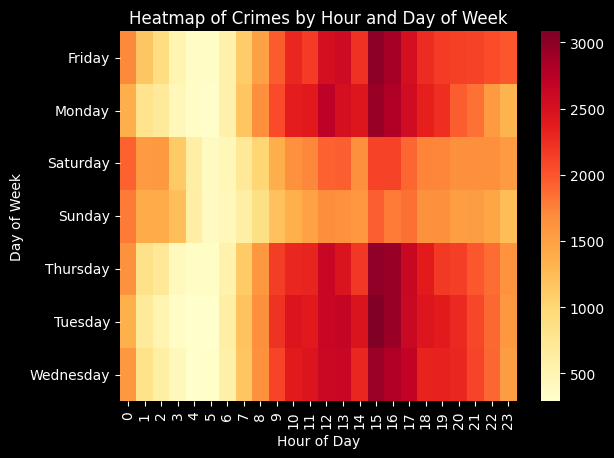

In [40]:
cd['hour']=cd['Dispatch Date / Time'].dt.hour
cd['day_of_week']=cd['Dispatch Date / Time'].dt.day_name()
hourly_crimes = cd.groupby(['day_of_week', 'hour']).size().unstack()
sns.heatmap(hourly_crimes, cmap='YlOrRd')
plt.title('Heatmap of Crimes by Hour and Day of Week')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.show()

Seasonal crime or Monthly trends in crime counts

Plot Type: Line Plot


/var/folders/s0/0t4b0q1x7rj9l6hs1khgqxsr0000gn/T/ipykernel_86261/211486455.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_crimes = cd.groupby(['month', 'Crime Name1']).size().unstack()


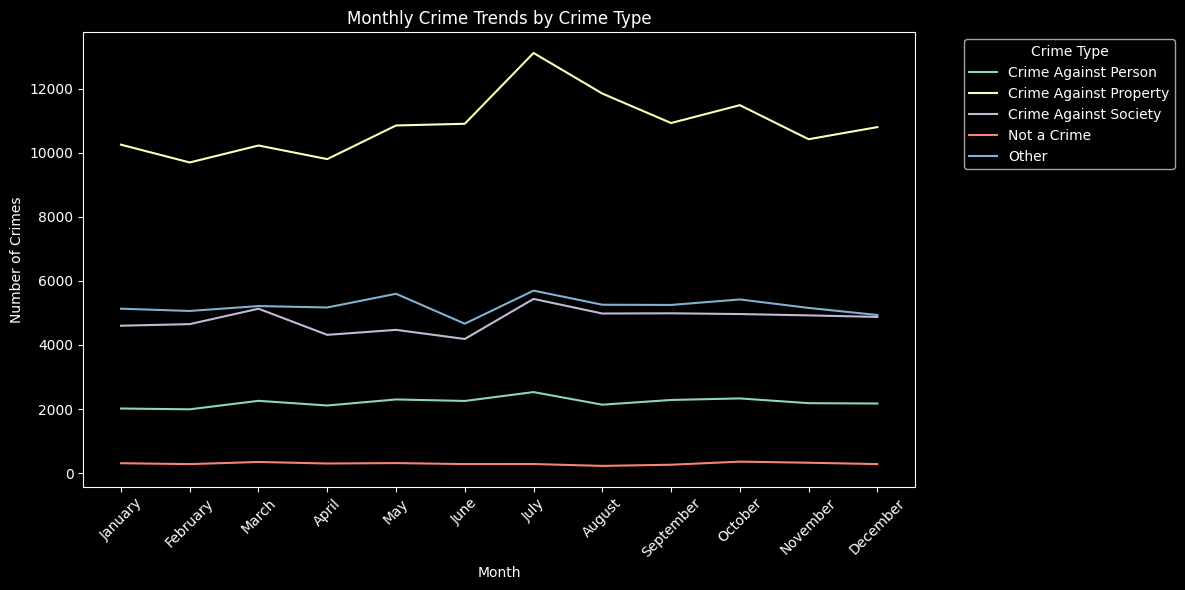

In [41]:
# use seaborn
cd['month']=cd['Dispatch Date / Time'].dt.month
monthly_crimes = cd.groupby(['month', 'Crime Name1']).size().unstack()
month_names = {1: 'January', 2: 'February', 3: 'March', 4: 'April', 5: 'May', 6: 'June',
               7: 'July', 8: 'August', 9: 'September', 10: 'October', 11: 'November', 12: 'December'}
monthly_crimes.plot(figsize=(12, 6))
#use Seaborn
plt.title('Monthly Crime Trends by Crime Type')
plt.xlabel('Month')
plt.ylabel('Number of Crimes')
plt.xticks(ticks=range(1, 13), labels=[month_names[i] for i in range(1, 13)], rotation=45)
plt.legend(title='Crime Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



In [42]:
# Geospatial Visualization using geopandas
#make different color for different crime types
gdf = gpd.GeoDataFrame(cd, geometry=gpd.points_from_xy(cd.Longitude, cd.Latitude))
#First just test the map
world = gpd.read_file('./Maps/tl_2023_18107_faces.shp')




In [69]:
cd['Police District Name'].unique()

array(['GERMANTOWN', 'BETHESDA', 'MONTGOMERY VILLAGE', 'WHEATON',
       'SILVER SPRING', 'ROCKVILLE', 'CITY OF TAKOMA PARK', 'OTHER',
       'TAKOMA PARK'], dtype=object)

In [70]:
cd[cd['Police District Name']=='OTHER']

,Incident ID,Offence Code,CR Number,Dispatch Date / Time,NIBRS Code,Victims,Crime Name1,Crime Name2,Crime Name3,Police District Name,Block Address,City,State,Zip Code,Agency,Place,Sector,Beat,PRA,Address Number,Street Prefix,Street Name,Street Suffix,Street Type,Start_Date_Time,End_Date_Time,Latitude,Longitude,Police District Number,Location
185,201336300,2303,210024908,2021-06-29 11:47:11,23C,1,Crime Against Property,Shoplifting,LARCENY - SHOPLIFTING,OTHER,5300 BLK WISCONSIN AVE NW,CHEVY CHASE,DC,20815,MCPD,Retail - Department/Discount Store,NaN,NaN,NaN,5300,NaN,WISCONSIN,NW,AVE,2021-06-27 16:00:00,2021-06-27 16:05:00,39.010354,-77.138009,OTHER,"(0.0, 0.0)"
2486,201343436,2404,210033807,2021-08-30 06:41:43,240,1,Crime Against Property,Motor Vehicle Theft,AUTO THEFT - VEHICLE THEFT,OTHER,3400 BLK MASSACHUSETTS AVE NW,WASHINGTON,DC,20007,MCPD,Street - In vehicle,NaN,NaN,NaN,3400,NaN,MASSACHUSETTS,NW,AVE,2021-08-30 06:41:00,NaN,39.061747,-76.975140,OTHER,"(0.0, 0.0)"
2701,201339773,5016,210029331,2021-06-03 11:48:00,90Z,1,Crime Against Society,All Other Offenses,OBSTRUCT GOVT - VIOLATION OF A COURT ORDER,OTHER,18100 BLK HIGHFIELD RD,ASHTON,MD,20861,MCPD,Residence - Single Family,NaN,NaN,NaN,18100,NaN,HIGHFIELD,NaN,RD,2021-06-03 11:48:00,NaN,39.140023,-77.190654,OTHER,"(39.1532, -76.9868)"
2818,201353229,9199,210045396,2021-11-09 15:18:41,90Z,1,Other,All Other Offenses,POLICE INFORMATION,OTHER,10400 BLK EDGEFIELD DR,HYATTSVILLE,MD,20783,MCPD,Park,NaN,NaN,NaN,10400,NaN,EDGEFIELD,NaN,DR,2021-11-09 14:30:00,NaN,39.061747,-76.975140,OTHER,"(0.0, 0.0)"
4758,201342349,2610,210032493,2021-08-20 16:11:36,26F,1,Crime Against Property,Identity Theft,IDENTITY THEFT,OTHER,1800 BLK MT PISGAH LA,SILVER SPRING,MD,20903,MCPD,Bank/S&L/Credit Union,NaN,NaN,NaN,1800,NaN,MT PISGAH,NaN,LA,2021-08-20 17:11:00,NaN,39.189527,-77.239600,OTHER,"(0.0, 0.0)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
262911,201316497,2999,200050842,2020-12-26 15:36:02,290,1,Crime Against Property,Destruction/Damage/Vandalism of Property,DAMAGE PROPERTY (DESCRIBE OFFENSE),OTHER,8500 BLK NEW HAMPSHIRE AVE,HYATTSVILLE,MD,20783,MCPD,Street - Residential,NaN,NaN,NaN,8500,NaN,NEW HAMPSHIRE,NaN,AVE,2020-12-26 15:00:00,2020-12-26 15:10:00,NaN,NaN,OTHER,"(0.0, 0.0)"
266632,201315848,3562,210001165,2021-01-09 23:15:28,35A,1,Crime Against Society,Drug/Narcotic Violations,DRUGS - MARIJUANA - POSSESS,OTHER,7900 BLK NEW HAMPSHIRE AVE,HYATTSVILLE,MD,20783,TPPD,Street - Alley,NaN,NaN,NaN,7900,NaN,NEW HAMPSHIRE,NaN,AVE,2021-01-09 23:16:00,NaN,NaN,NaN,OTHER,"(0.0, 0.0)"
269237,201303585,1213,200037920,2020-09-26 20:53:58,120,1,Crime Against Property,Robbery,ROBBERY - GUN,OTHER,Unknown Block of PINEY BRANCH Unknown Suffix RMP,SILVER SPRING,MD,20783,MCPD,Street - Residential,NaN,NaN,NaN,0,NaN,PINEY BRANCH,NaN,RMP,2020-09-25 19:00:00,2020-09-25 20:00:00,NaN,NaN,OTHER,"(0.0, 0.0)"
269975,201306516,2103,200041455,2020-10-20 19:21:57,210,1,Crime Against Property,Extortion/Blackmail,EXTORT - THREAT INJURE REPUTATION,OTHER,3200 BLK TOLEDO PL,HYATTSVILLE,MD,20782,MCPD,Residence -Townhouse/Duplex,NaN,NaN,NaN,3200,NaN,TOLEDO,NaN,PL,2020-10-20 20:59:00,NaN,NaN,NaN,OTHER,"(0.0, 0.0)"


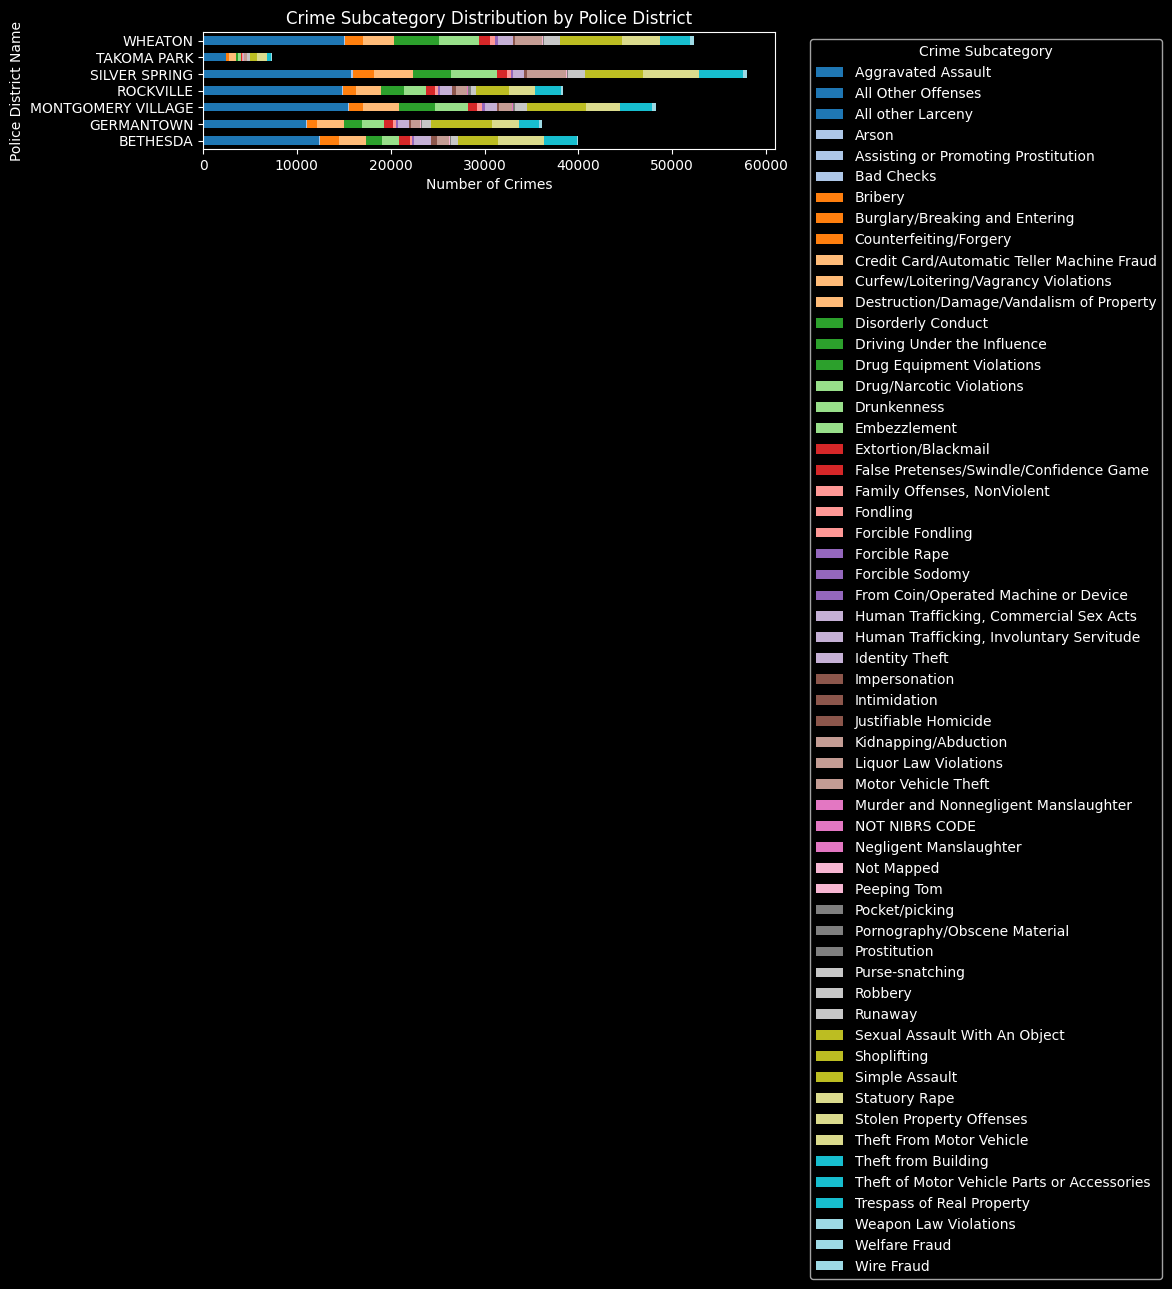

In [77]:
#Make bar chart for Crime and thier sub categories for each Police District Name Don't include OTHER
#Crime Name1 is main category and Crime Name2 is sub category 
# Bar chart crime go horizontally
df = cd[cd['Police District Name'] != 'OTHER']

# Group by Police District and Crime Name2 (subcategory)
crime_counts = df.groupby(['Police District Name', 'Crime Name2']).size().unstack(fill_value=0)

# Plot horizontal stacked bar chart
crime_counts.plot(kind='barh', stacked=True, figsize=(12, 8), colormap='tab20')

plt.title('Crime Subcategory Distribution by Police District')
plt.xlabel('Number of Crimes')
plt.ylabel('Police District Name')
plt.legend(title='Crime Subcategory', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()




In [80]:
cd['Crime Name1'].isna().sum()

np.int64(238)

In [81]:
# drop all entry if they have na value in Crime Name1
cd = cd.dropna(subset=['Crime Name1'])
cd.to_csv('./data/Crime_Dataset_Cleaned.csv', index=False)